In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


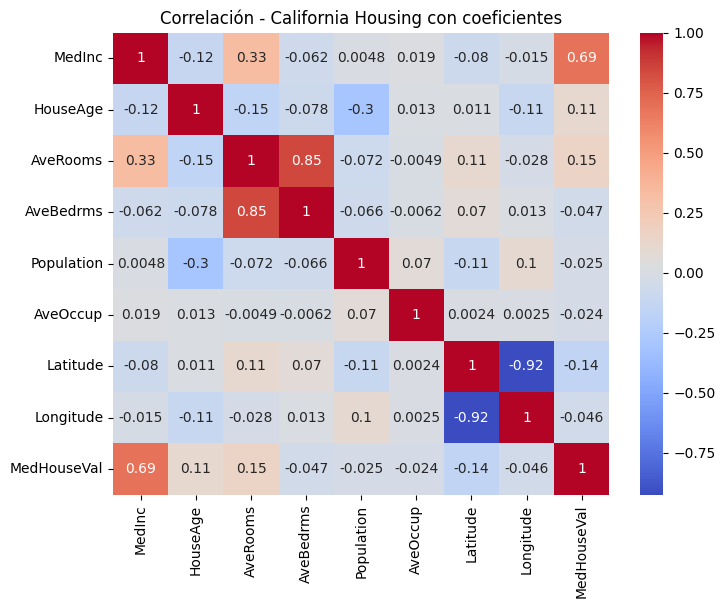

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlación - California Housing con coeficientes")
plt.show()

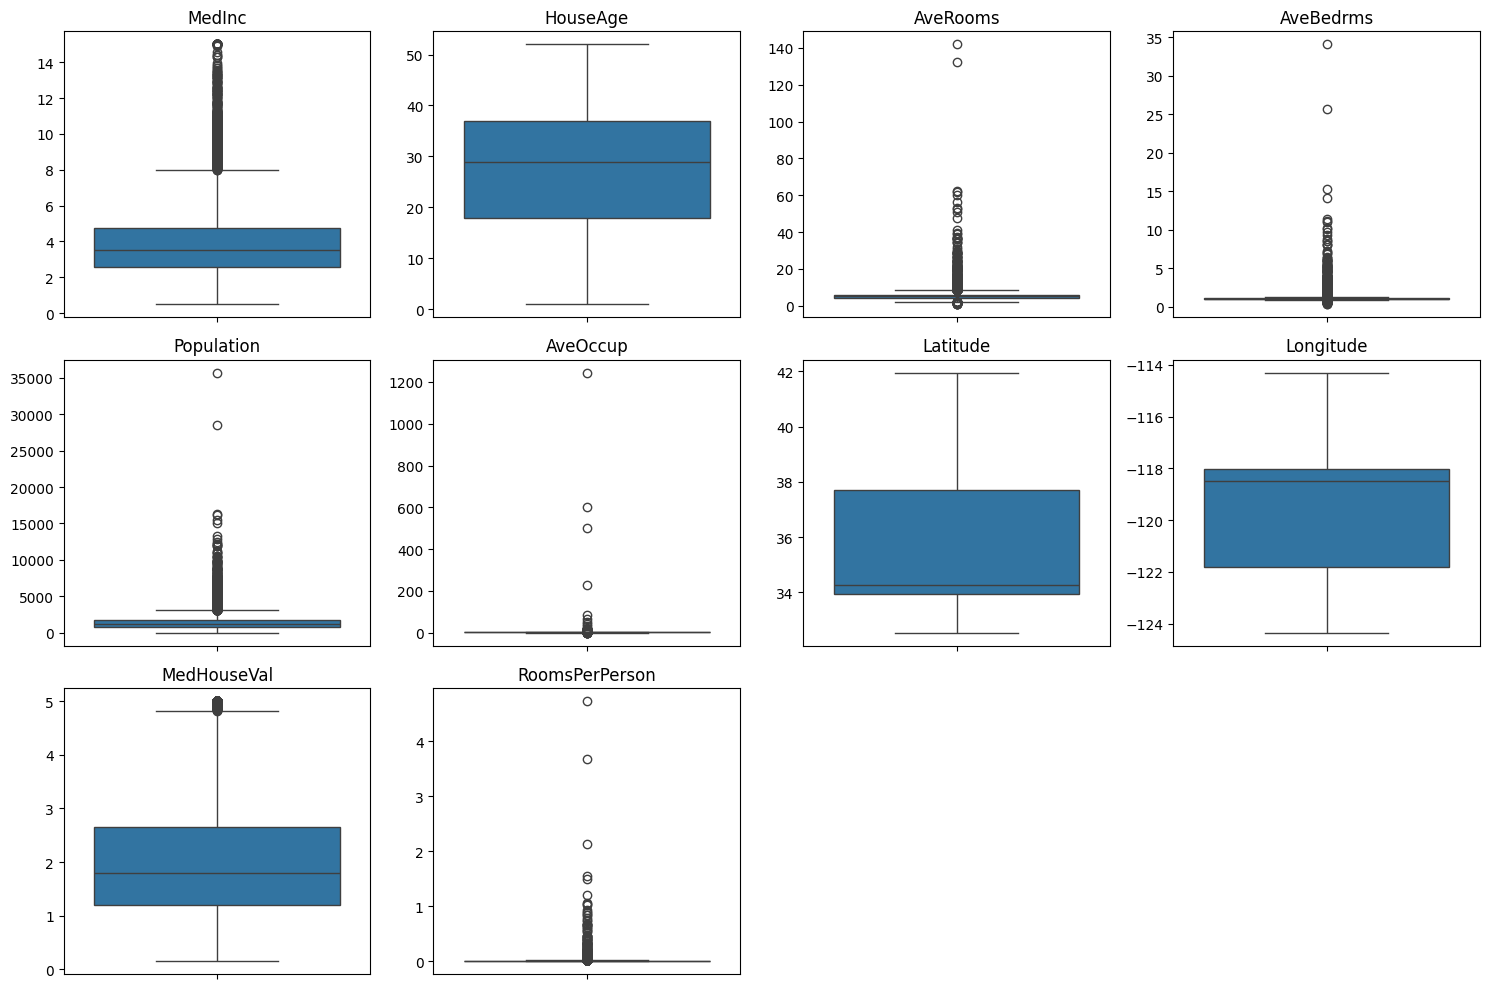

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(column)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Exclude the target variable 'MedHouseVal' for VIF calculation
X = df.drop('MedHouseVal', axis=1)

# Add a constant to the DataFrame (required for VIF calculation)
X_const = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:
      feature           VIF
0       const  17082.623698
7    Latitude      9.297624
8   Longitude      8.962263
3    AveRooms      8.342786
4   AveBedrms      6.994995
1      MedInc      2.501295
2    HouseAge      1.241254
5  Population      1.138125
6    AveOccup      1.008324


VIF de AveRooms y AveBedrms ≈ 8–15
Esto es riesgo moderado-alto

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
r2_scaled = r2_score(y_test, y_pred)

r2_scaled

0.5760737799504685

In [ ]:
X2 = df.drop(columns=['MedHouseVal', 'AveBedrms'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler for the second model
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

lr2 = LinearRegression()
lr2.fit(X_train2_scaled, y_train2)

y_pred2 = lr2.predict(X_test2_scaled)
r2_reduced = r2_score(y_test2, y_pred2)

r2_reduced

0.5818043980133083

In [ ]:
import pandas as pd

# Get coefficients and intercept for the original model (lr)
original_coefs = dict(zip(X.columns, lr.coef_))
original_coefs['const'] = lr.intercept_

# Get coefficients and intercept for the reduced model (lr2)
reduced_coefs = dict(zip(X2.columns, lr2.coef_))
reduced_coefs['const'] = lr2.intercept_

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Original Model (lr)': pd.Series(original_coefs),
    'Reduced Model (lr2)': pd.Series(reduced_coefs)
})

print(comparison_df.sort_index())

                Original Model (lr)  Reduced Model (lr2)
AveBedrms                  0.340523                  NaN
AveOccup                  -0.040804            -0.037826
AveRooms                  -0.293241             0.023285
HouseAge                   0.122656             0.122369
Latitude                  -0.897675            -0.968660
Longitude                 -0.870532            -0.923293
MedInc                     0.854071             0.716116
Population                -0.002498            -0.001529
RoomsPerPerson            -0.003361             0.030854
const                      2.071947             2.071947


Regularización con Ridge

In [ ]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model with X2 data
ridge_model2 = Ridge(random_state=42)
ridge_model2.fit(X_train2_scaled, y_train2)

# Make predictions and calculate R-squared for the Ridge model with X2 data
y_pred_r2 = ridge_model2.predict(X_test2_scaled)
r2_ridge2 = r2_score(y_test2, y_pred_r2)

print(f"R-squared for Ridge Regression with X2 data: {r2_ridge2}")

R-squared for Ridge Regression with X2 data: 0.5818042856584511


In [ ]:
import pandas as pd

# Get coefficients and intercept for the original model (lr)
original_coefs = dict(zip(X.columns, lr.coef_))
original_coefs['const'] = lr.intercept_

# Get coefficients and intercept for the reduced model (lr2)
reduced_coefs = dict(zip(X2.columns, lr2.coef_))
reduced_coefs['const'] = lr2.intercept_

# Get coefficients and intercept for the Ridge model (ridge_model2)
ridge_coefs = dict(zip(X2.columns, ridge_model2.coef_))
ridge_coefs['const'] = ridge_model2.intercept_

# Create a DataFrame for coefficient comparison
comparison_df_coefs = pd.DataFrame({
    'Original LR (lr)': pd.Series(original_coefs),
    'Reduced LR (lr2)': pd.Series(reduced_coefs),
    'Ridge Reg (ridge_model2)': pd.Series(ridge_coefs)
}).sort_index()

# Create a DataFrame for R2 score comparison
comparison_df_r2 = pd.DataFrame({
    'Model': ['Original LR (lr)', 'Reduced LR (lr2)', 'Ridge Reg (ridge_model2)'],
    'R2 Score': [r2_scaled, r2_reduced, r2_ridge2]
})

print("\n--- Coefficients Comparison ---\n")
print(comparison_df_coefs)

print("\n--- R2 Score Comparison ---\n")
print(comparison_df_r2.set_index('Model'))


--- Coefficients Comparison ---

                Original LR (lr)  Reduced LR (lr2)  Ridge Reg (ridge_model2)
AveBedrms               0.340523               NaN                       NaN
AveOccup               -0.040804         -0.037826                 -0.037834
AveRooms               -0.293241          0.023285                  0.023168
HouseAge                0.122656          0.122369                  0.122452
Latitude               -0.897675         -0.968660                 -0.967732
Longitude              -0.870532         -0.923293                 -0.922375
MedInc                  0.854071          0.716116                  0.716208
Population             -0.002498         -0.001529                 -0.001500
RoomsPerPerson         -0.003361          0.030854                  0.030893
const                   2.071947          2.071947                  2.071947

--- R2 Score Comparison ---

                          R2 Score
Model                             
Original LR (lr)   

# Task
Apply PCA to `X_train_scaled` and `X_test_scaled` datasets, then visualize the explained variance to determine the optimal number of components. After transforming the data using the selected components, train a Linear Regression model and evaluate its performance with R-squared. Finally, compare the R-squared score of this PCA-based model with the existing `r2_scaled`, `r2_reduced`, and `r2_ridge2` scores, presenting a comprehensive comparison of all model results.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA() # Do not specify n_components to analyze all components
pca.fit(X_train_scaled)

print("PCA fitted successfully to X_train_scaled.")

PCA fitted successfully to X_train_scaled.


## Analyze Explained Variance

### Subtask:
Plot the explained variance ratio to determine the optimal number of principal components.


**Reasoning**:
To visualize the explained variance, I need to calculate the cumulative sum of the explained variance ratios and then plot both the individual and cumulative explained variance. This will help in determining the optimal number of principal components.



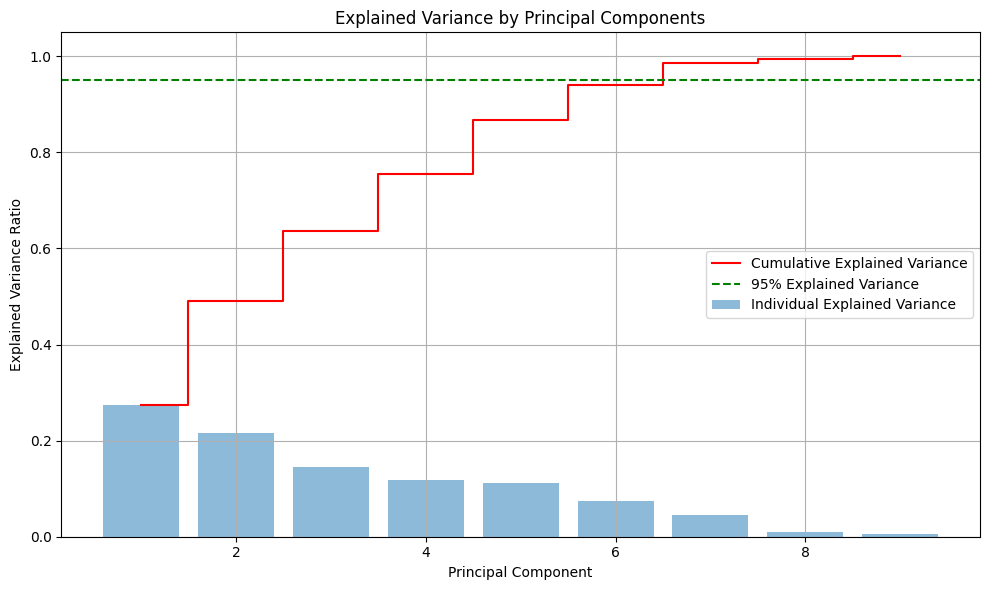

Number of components to explain 95% variance: 7


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Create the plot
plt.figure(figsize=(10, 6))

plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual Explained Variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Cumulative Explained Variance', color='red')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% Explained Variance')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Print the number of components for 95% variance
num_components_95 = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% variance: {num_components_95}")

## Transform Data with Optimal Components

### Subtask:
Apply PCA transformation using the chosen number of components (7) to the training and testing data.


**Reasoning**:
To transform the data using PCA with the optimal number of components, I will instantiate a new PCA object with `n_components=7`, fit it to the scaled training data, and then transform both the scaled training and testing data.



In [ ]:
pca_final = PCA(n_components=7)
pca_final.fit(X_train_scaled)

X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Data transformed using PCA with 7 components.")

Data transformed using PCA with 7 components.


**Reasoning**:
Now that the data has been transformed using PCA, I will train a Linear Regression model on the `X_train_pca` and `y_train` datasets and then evaluate its performance using `r2_score` on the `X_test_pca` and `y_test` datasets. This will allow for comparison with previously calculated R-squared scores.



In [ ]:
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print(f"R-squared for Linear Regression with PCA components: {r2_pca}")

R-squared for Linear Regression with PCA components: 0.49006128131156657


**Reasoning**:
To provide a comprehensive comparison, I will create a pandas DataFrame that consolidates the R-squared scores from all models: the original linear regression (`r2_scaled`), the reduced linear regression (`r2_reduced`), the Ridge regression (`r2_ridge2`), and the new PCA-based linear regression (`r2_pca`). Then, I will print this DataFrame.



In [ ]:
import pandas as pd

# Create a DataFrame for R2 score comparison, including the PCA model
comparison_df_r2_all = pd.DataFrame({
    'Model': ['Original LR (lr)', 'Reduced LR (lr2)', 'Ridge Reg (ridge_model2)', 'PCA LR (lr_pca)']
})

# Append R2 scores to the DataFrame
comparison_df_r2_all['R2 Score'] = [r2_scaled, r2_reduced, r2_ridge2, r2_pca]

print("\n--- Comprehensive R2 Score Comparison ---\n")
print(comparison_df_r2_all.set_index('Model'))


--- Comprehensive R2 Score Comparison ---

                          R2 Score
Model                             
Original LR (lr)          0.576074
Reduced LR (lr2)          0.581804
Ridge Reg (ridge_model2)  0.581804
PCA LR (lr_pca)           0.490061


## Summary:

### Q&A
The R-squared score of the PCA-based Linear Regression model (approximately 0.490) was compared with other models:
*   Original Linear Regression on scaled data (`r2_scaled`): 0.576074
*   Reduced Linear Regression (`r2_reduced`): 0.581804
*   Ridge Regression (`r2_ridge2`): 0.581804
The PCA-based model achieved a lower R-squared score compared to the other evaluated models.

### Data Analysis Key Findings
*   PCA was successfully applied to the `X_train_scaled` dataset.
*   An analysis of the explained variance indicated that **7 principal components** are required to explain **95%** of the total variance in the dataset.
*   A Linear Regression model trained on data transformed using these 7 PCA components yielded an R-squared score of approximately **0.490**.
*   In a comprehensive comparison, the PCA-based Linear Regression model's R-squared score of 0.490 was lower than that of the Original Linear Regression (0.576), Reduced Linear Regression (0.582), and Ridge Regression (0.582) models.

### Insights or Next Steps
*   Despite retaining 95% of the variance, the PCA-transformed data led to a Linear Regression model with lower predictive performance (R-squared of 0.490) compared to models built on the original or reduced feature sets (R-squared around 0.58). This suggests that the principal components explaining the most variance may not necessarily be the most correlated with the target variable, or that crucial information for prediction was lost.
*   Further investigation could explore using a different number of principal components (e.g., fewer to avoid overfitting noise, or more if 95% was too aggressive), or consider alternative dimensionality reduction techniques that are more sensitive to the target variable's relationship (e.g., methods incorporating supervised information).
